# 02 · Algorytm genetyczny w planowaniu produkcji
## Ile partii każdego produktu wytworzyć przy ograniczonych zasobach?


Zakład wytwarza osiem rodzajów elementów metalowych. Każda partia zajmuje materiał i czas kilku stanowisk, daje inną marżę i ma ograniczony popyt. Szukamy planu z największą łączną marżą, który mieści się w dostępnych zasobach.

To **w pełni rozwiązany notebook**: wszystkie komórki, porównania, analiza wąskich gardeł i scenariusze dodatkowe mają gotowe rozwiązania oraz zapisane wyniki. Nie trzeba wczytywać zewnętrznych danych.

**Po tym przykładzie potrafisz:** zapisać plan jako wektor liczb całkowitych, odróżnić funkcję celu od dopuszczalności, zastosować selekcję preferującą plany wykonalne, ocenić GA względem solvera MILP i sprawdzić wpływ zwiększenia zasobów.

> Wszystkie parametry są syntetyczne i służą dydaktyce. „Marża” oznacza tu założoną nadwyżkę na partii po kosztach zmiennych; nie jest zyskiem netto przedsiębiorstwa.

### Uruchomienie

W Google Colab, JupyterLab lub VS Code wybierz **Uruchom wszystkie / Run all**. Wyniki są już zapisane w pliku. Notebook jest niezależny od przykładu z trasami.

Biblioteki: `numpy`, `pandas`, `matplotlib`, `scipy` i `ipython`. Funkcja `scipy.optimize.milp` wymaga SciPy 1.9 lub nowszego. Jeśli lokalnie brakuje pakietów, uruchom w osobnej komórce: `%pip install numpy pandas matplotlib "scipy>=1.9" ipython`. Nie potrzeba API, dostępu do firmowego systemu ani połączenia z internetem podczas obliczeń.

In [1]:
import sys
import time
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({
    'figure.dpi': 115,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.labelcolor': '#334155',
    'axes.grid': True,
    'grid.alpha': 0.18,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8fafc',
})
COLORS = {'ga': '#0f766e', 'base': '#64748b', 'exact': '#b45309', 'accent': '#7c3aed'}
pd.set_option('display.max_columns', 14)
pd.set_option('display.width', 150)
print(f'Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {matplotlib.__version__}')

import scipy
from scipy.optimize import milp, Bounds, LinearConstraint
print(f'SciPy {scipy.__version__}')

Python 3.12.14 | NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
SciPy 1.17.0


### 1. Dane: decyzja w partiach, zasoby w swoich jednostkach

Jeden gen to liczba partii danego wyrobu. Dopuszczamy zero: produkt może nie wejść do bieżącego planu. Górną granicą jest popyt. Nie zakładamy obowiązku obsłużenia wszystkich zamówień ani minimalnej partii większej od jednej.

To **plan ilościowy na jeden okres**, a nie harmonogram kolejności operacji na maszynach. Dostępność zasobów jest sumaryczna. Model nie sprawdza, o której godzinie konkretna partia zajmie spawarkę.

In [2]:
products = pd.DataFrame({
    'Produkt': ['Panel standard', 'Panel premium', 'Furtka', 'Brama lekka',
                'Brama ciężka', 'Słupek', 'Balustrada', 'Rama przemysłowa'],
    'Marża [zł/partię]': [460, 650, 710, 980, 1250, 380, 700, 850],
    'Popyt [partie]': [18, 16, 14, 12, 10, 15, 10, 9],
    'Stal [kg/partię]': [38, 45, 55, 70, 95, 32, 48, 62],
    'Cięcie [min/partię]': [20, 28, 25, 42, 55, 18, 32, 37],
    'Spawanie [min/partię]': [30, 45, 35, 60, 75, 28, 42, 48],
    'Malowanie [min/partię]': [18, 20, 25, 30, 35, 16, 24, 28],
})
resource_columns = ['Stal [kg/partię]', 'Cięcie [min/partię]',
                    'Spawanie [min/partię]', 'Malowanie [min/partię]']
resource_names = ['Stal [kg]', 'Cięcie [min]', 'Spawanie [min]', 'Malowanie [min]']
profit = products['Marża [zł/partię]'].to_numpy(dtype=float)
demand = products['Popyt [partie]'].to_numpy(dtype=int)
A = products[resource_columns].to_numpy(dtype=float).T
CAPACITY = np.array([1900, 980, 1450, 700], dtype=float)
P = len(products)

display(products)
display(pd.DataFrame({'Zasób': resource_names, 'Dostępność': CAPACITY}))
print(f'Liczba planów ograniczonych samym popytem: {math.prod(int(v)+1 for v in demand):,}')

Liczba planów ograniczonych samym popytem: 1,219,389,600


,Produkt,Marża [zł/partię],Popyt [partie],Stal [kg/partię],Cięcie [min/partię],Spawanie [min/partię],Malowanie [min/partię]
0,Panel standard,460,18,38,20,30,18
1,Panel premium,650,16,45,28,45,20
2,Furtka,710,14,55,25,35,25
3,Brama lekka,980,12,70,42,60,30
4,Brama ciężka,1250,10,95,55,75,35
5,Słupek,380,15,32,18,28,16
6,Balustrada,700,10,48,32,42,24
7,Rama przemysłowa,850,9,62,37,48,28


,Zasób,Dostępność
0,Stal [kg],1900.0
1,Cięcie [min],980.0
2,Spawanie [min],1450.0
3,Malowanie [min],700.0


### 2. Matematyka modelu i reguła wykonalności

\[
\max_x p^T x \qquad \text{przy } Ax\leq b,\quad 0\leq x_i\leq u_i,\quad x_i\in\mathbb{Z}.
\]

`p` to marże, `x` — liczby partii, `A` — zużycie zasobów na partię, `b` — dostępności, `u` — popyty. Wiersz macierzy `A` jest zasobem; kolumna jest produktem.

**Przekroczenia normalizujemy**, bo nie można sensownie dodawać kilogramów do minut:

\[
v(x)=\sum_j \max\left(0,\frac{(Ax)_j-b_j}{b_j}\right).
\]

Ta liczba mierzy naruszenia, lecz nie jest kosztem pieniężnym. Nie odejmujemy jej od marży za pomocą arbitralnie dobranej kary. Porównujemy osobniki następująco:

1. Każdy plan dopuszczalny wygrywa z niedopuszczalnym.
2. Wśród dopuszczalnych wygrywa wyższa marża.
3. Wśród niedopuszczalnych wygrywa mniejsze łączne względne przekroczenie, a przy remisie — wyższa marża.

Granice genów i całkowitość utrzymują operatory. Sprawdzenie końcowe obejmie wszystkie ograniczenia.

In [3]:
def evaluate_plans(population, capacity):
    population = np.atleast_2d(np.asarray(population))
    assert np.all(capacity > 0), 'W tym przykładzie każda dostępność musi być dodatnia.'
    assert population.shape[1] == P
    assert np.all(population == np.rint(population))
    assert np.all(population >= 0) and np.all(population <= demand)
    margins = population @ profit
    usage = population @ A.T
    violation = np.maximum(usage / capacity - 1.0, 0.0).sum(axis=1)
    feasible = np.all(usage <= capacity + 1e-9, axis=1)
    return margins, usage, violation, feasible


def rank_plans(margins, violation, feasible):
    # np.lexsort: ostatni klucz jest najważniejszy.
    # W granicach tolerancji wykonalność ma pierwszeństwo przed resztką numeryczną.
    effective_violation = np.where(feasible, 0.0, violation)
    return np.lexsort((-margins, effective_violation, (~feasible).astype(int)))


def plan_is_feasible(plan, capacity=CAPACITY):
    plan = np.asarray(plan)
    return (plan.shape == (P,) and np.all(plan == np.rint(plan))
            and np.all(plan >= 0) and np.all(plan <= demand)
            and np.all(A @ plan <= capacity + 1e-8))


demo_plans = np.array([np.zeros(P, dtype=int), np.full(P, 3), demand])
margins, usage, violation, feasible = evaluate_plans(demo_plans, CAPACITY)
display(pd.DataFrame({
    'Plan': ['Nic nie produkuj', 'Po 3 partie każdego wyrobu', 'Zrealizuj cały popyt'],
    'Marża [zł]': margins, 'Wykonalny': feasible, 'Względne przekroczenie': violation,
}).round(3))
print('Kolejność według reguły selekcji:', rank_plans(margins, violation, feasible))

Kolejność według reguły selekcji: [1 0 2]


,Plan,Marża [zł],Wykonalny,Względne przekroczenie
0,Nic nie produkuj,0.0,True,0.000
1,Po 3 partie każdego wyrobu,17940.0,True,0.000
2,Zrealizuj cały popyt,73230.0,False,8.662


### 3. Metoda bazowa: zachłanne wykorzystanie zasobów

Tworzymy heurystyczny wskaźnik: marża partii podzielona przez sumę udziałów tej partii w dostępnych zasobach. Następnie, zaczynając od najwyższego wskaźnika, dokładamy partię, jeżeli mieści się we wszystkich limitach.

Wskaźnik nie jest ceną ekonomiczną zasobów. Traktuje zasoby według udziałów w ich dostępności i może błędnie wycenić wąskie gardło. To użyteczna metoda porównawcza, ale nie dowód optymalności.

In [4]:
def greedy_plan(capacity):
    resource_load = (A / capacity[:, None]).sum(axis=0)
    score = profit / resource_load
    order = np.argsort(-score)
    plan = np.zeros(P, dtype=int)
    for product_id in order:
        while plan[product_id] < demand[product_id]:
            candidate = plan.copy()
            candidate[product_id] += 1
            if np.all(A @ candidate <= capacity + 1e-9):
                plan = candidate
            else:
                break
    return plan


t0 = time.perf_counter()
greedy = greedy_plan(CAPACITY)
greedy_seconds = time.perf_counter() - t0
print('Plan zachłanny:', greedy)
print(f'Marża: {profit @ greedy:,.0f} zł | wykonalny: {plan_is_feasible(greedy)}')

Plan zachłanny: [ 0  0 14  0 10  0  0  0]
Marża: 22,440 zł | wykonalny: True


### 4. Populacja startowa i operatory całkowitoliczbowe

Losowanie każdej liczby od zera do popytu daje dużo niewykonalnych planów. Dlatego **jedną trzecią startowych planów skalujemy w dół** względem najbardziej przeciążonego zasobu i zaokrąglamy w dół. Te plany są wykonalne, bo zużycia są nieujemne. Dodajemy również plan zerowy. Pozostałe osobniki mogą naruszać dostępności.

Nie wprowadzamy do populacji wyniku heurystyki ani solvera. Start ma zapewnić dostęp do obszaru wykonalnego, a nie gotowe rozwiązanie.

**Krzyżowanie równomierne:** każdą liczbę partii dziedziczymy losowo z jednego z rodziców. **Mutacja lokalna:** wybrane geny zmieniamy o `−2`, `−1`, `+1` albo `+2`. **Rzadki reset:** gen może otrzymać zupełnie nową liczbę z zakresu popytu. Po mutacji przycinamy wartości do granic. Wykonalność zasobową rozstrzyga selekcja — nie maskujemy przekroczeń zaokrągleniem.

In [5]:
def initial_population(size, rng, capacity):
    population = rng.integers(0, demand + 1, size=(size, P))
    count = max(1, size // 3)
    subset = population[:count].astype(float)
    load = np.max((subset @ A.T) / capacity, axis=1)
    factor = rng.uniform(0.5, 1.0, size=count) / np.maximum(load, 1.0)
    population[:count] = np.floor(subset * factor[:, None]).astype(int)
    population[0] = 0
    return population


def make_children(population, order, count, rng,
                  tournament_size=3, mutation_rate=0.24, reset_rate=0.04):
    # rank_by_index zamienia wynik wielokryterialny na rangę osobnika.
    rank_by_index = np.empty(len(population), dtype=int)
    rank_by_index[order] = np.arange(len(population))

    def select_parents():
        candidates = rng.integers(0, len(population), size=(count, tournament_size))
        best_columns = np.argmin(rank_by_index[candidates], axis=1)
        winners = candidates[np.arange(count), best_columns]
        return population[winners]

    a, b = select_parents(), select_parents()
    children = np.where(rng.random((count, P)) < 0.5, a, b)
    mutate = rng.random((count, P)) < mutation_rate
    steps = rng.choice([-2, -1, 1, 2], size=(count, P))
    children = children + mutate * steps
    reset = rng.random((count, P)) < reset_rate
    fresh_values = rng.integers(0, demand + 1, size=(count, P))
    children = np.where(reset, fresh_values, children)
    return np.clip(children, 0, demand).astype(int)


demo_rng = np.random.default_rng(3)
demo_population = initial_population(12, demo_rng, CAPACITY)
demo_margin, _, demo_violation, demo_feasible = evaluate_plans(demo_population, CAPACITY)
demo_order = rank_plans(demo_margin, demo_violation, demo_feasible)
demo_children = make_children(demo_population, demo_order, 4, demo_rng)
display(pd.DataFrame(demo_children, columns=products['Produkt']))
print('Dzieci mają całkowite geny w granicach popytu; ograniczenia zasobów ocenimy osobno.')

Dzieci mają całkowite geny w granicach popytu; ograniczenia zasobów ocenimy osobno.


Produkt,Panel standard,Panel premium,Furtka,Brama lekka,Brama ciężka,Słupek,Balustrada,Rama przemysłowa
0,0,4,2,1,4,4,1,0
1,4,5,3,2,0,3,2,2
2,0,0,2,0,1,2,3,2
3,2,15,2,7,0,3,2,2


### 5. Pełna pętla GA

Elity wybieramy zgodnie z regułą wykonalności. Ponieważ od początku istnieje plan dopuszczalny, zachowanie co najmniej jednej elity sprawia, że nigdy go nie utracimy. Najlepsza **dopuszczalna** marża nie powinna maleć.

W historii zapisujemy też procent planów dopuszczalnych i medianę marży wyłącznie takich planów. Wysoka marża planu niemożliwego do wykonania nie jest sukcesem.

W tym notebooku `mutation_rate` i `reset_rate` działają **na pojedynczy gen**. To inna semantyka niż prawdopodobieństwo mutacji całej trasy w notebooku 01.

In [6]:
def genetic_production(capacity, pop_size=180, generations=220,
                       elite_size=4, tournament_size=3,
                       mutation_rate=0.24, reset_rate=0.04, seed=7):
    assert pop_size >= 4 and generations >= 1 and 1 <= elite_size < pop_size
    assert 0 <= mutation_rate <= 1 and 0 <= reset_rate <= 1 and tournament_size >= 1
    rng = np.random.default_rng(seed)
    population = initial_population(pop_size, rng, capacity)
    history = []
    started = time.perf_counter()

    for generation in range(generations + 1):
        margins, usage, violation, feasible = evaluate_plans(population, capacity)
        order = rank_plans(margins, violation, feasible)
        feasible_margins = margins[feasible]
        assert len(feasible_margins) > 0
        history.append({
            'pokolenie': generation,
            'najlepsza_marza': float(np.max(feasible_margins)),
            'mediana_marzy_wykonalnych': float(np.median(feasible_margins)),
            'udzial_wykonalnych': float(np.mean(feasible)),
            'udzial_roznych_planow': len(np.unique(population, axis=0)) / pop_size,
        })
        if generation == generations:
            break
        elites = population[order[:elite_size]].copy()
        children = make_children(population, order, pop_size - elite_size, rng,
                                 tournament_size, mutation_rate, reset_rate)
        population = np.vstack([elites, children])

    best = population[order[0]].copy()
    assert plan_is_feasible(best, capacity)
    return {'plan': best, 'margin': float(profit @ best),
            'history': pd.DataFrame(history),
            'evaluations': pop_size * (generations + 1),
            'seconds': time.perf_counter() - started}


CONFIG = dict(pop_size=180, generations=220, elite_size=4,
              tournament_size=3, mutation_rate=0.24, reset_rate=0.04)
ga = genetic_production(CAPACITY, seed=7, **CONFIG)
print(f"Najlepsza marża GA: {ga['margin']:,.0f} zł | {ga['evaluations']:,} ocen | {ga['seconds']:.2f} s")
print('Plan GA:', ga['plan'])

Najlepsza marża GA: 23,290 zł | 39,780 ocen | 0.09 s
Plan GA: [ 0  1  6  6 10  0  0  0]


### 6. Losowe przeszukiwanie z równym budżetem ocen

Losujemy tyle planów, ile ocen wykonał GA. Stosujemy tę samą mieszankę planów surowych i skalowanych jak w inicjalizacji GA. Dzięki temu punkt odniesienia nie polega wyłącznie na losowaniu przeważnie niewykonalnych planów.

Każdy kandydat, także niedopuszczalny, zużywa jedną ocenę. Zachowujemy plan z najwyższą marżą spośród dopuszczalnych. Równa liczba ocen nie daje równego czasu — GA dodatkowo selekcjonuje i krzyżuje.

In [7]:
def random_production_search(capacity, budget, seed=2026):
    rng = np.random.default_rng(seed)
    best, best_margin, feasible_count = np.zeros(P, dtype=int), 0.0, 0
    started = time.perf_counter()
    for start in range(0, budget, 2000):
        size = min(2000, budget - start)
        population = initial_population(size, rng, capacity)
        margins, _, _, feasible = evaluate_plans(population, capacity)
        feasible_count += int(feasible.sum())
        scores = np.where(feasible, margins, -np.inf)
        idx = int(np.argmax(scores))
        if scores[idx] > best_margin:
            best, best_margin = population[idx].copy(), float(scores[idx])
    return {'plan': best, 'margin': best_margin,
            'feasible_fraction': feasible_count / budget,
            'seconds': time.perf_counter() - started}


random_result = random_production_search(CAPACITY, ga['evaluations'])
print(f"Losowanie: {random_result['margin']:,.0f} zł; udział planów wykonalnych: {random_result['feasible_fraction']:.1%}")

Losowanie: 22,740 zł; udział planów wykonalnych: 35.2%


### 7. Niezależna referencja: solver MILP

Nasz bazowy model jest liniowy, a zmienne są całkowite. Dlatego można go rozwiązać jako MILP. SciPy minimalizuje funkcję celu, więc przekazujemy **ujemne marże**. `integrality=1` dla każdej zmiennej wymusza całkowitość.

Wynik uznajemy za referencję optymalną dopiero po sprawdzeniu statusu solvera, luki optymalności i wykonalności planu. Nie wystarczy samo otrzymanie tablicy `x`. Proszenie solvera o zerową względną lukę nie usuwa tolerancji arytmetyki zmiennoprzecinkowej.

**Uczciwy wniosek praktyczny:** dla tej małej, liniowej wersji zadania MILP jest zwykle lepszym wyborem wdrożeniowym. GA jest tu przejrzystym przykładem uczenia metody; zyskuje inne zastosowania, kiedy ocena wymaga np. trudnego do zlinearyzowania symulatora. Wtedy porównanie z innymi metodami nadal jest potrzebne.

In [8]:
def exact_production(capacity):
    started = time.perf_counter()
    result = milp(
        c=-profit,
        integrality=np.ones(P, dtype=int),
        bounds=Bounds(np.zeros(P), demand),
        constraints=LinearConstraint(A, np.full(len(capacity), -np.inf), capacity),
        options={'mip_rel_gap': 0.0, 'time_limit': 30.0},
    )
    elapsed = time.perf_counter() - started
    if result.status != 0 or not result.success or result.x is None:
        raise RuntimeError(f'Brak potwierdzonego optimum: {result.message}')
    if result.mip_gap is None or result.mip_gap > 1e-8:
        raise RuntimeError(f'Niezerowa luka solvera: {result.mip_gap}')
    plan = np.rint(result.x).astype(int)
    assert np.max(np.abs(result.x - plan)) < 1e-5
    assert plan_is_feasible(plan, capacity)
    assert np.isclose(profit @ plan, -result.fun, atol=1e-5, rtol=0)
    return {'plan': plan, 'margin': float(profit @ plan),
            'seconds': elapsed, 'status': int(result.status),
            'mip_gap': float(result.mip_gap)}


exact = exact_production(CAPACITY)
comparison = pd.DataFrame([
    ['Heurystyka zachłanna', float(profit @ greedy), greedy_seconds],
    ['Losowe przeszukiwanie', random_result['margin'], random_result['seconds']],
    ['Algorytm genetyczny', ga['margin'], ga['seconds']],
    ['MILP — optimum', exact['margin'], exact['seconds']],
], columns=['Metoda', 'Marża [zł]', 'Czas [s]'])
comparison['Luka do optimum [%]'] = np.maximum(0, 100 * (exact['margin'] - comparison['Marża [zł]']) / exact['margin'])
display(comparison.round(4))
print(f"Status MILP: {exact['status']} | luka solvera: {exact['mip_gap']:.8f}")

Status MILP: 0 | luka solvera: 0.00000000


,Metoda,Marża [zł],Czas [s],Luka do optimum [%]
0,Heurystyka zachłanna,22440.0,0.0004,3.6496
1,Losowe przeszukiwanie,22740.0,0.0128,2.3615
2,Algorytm genetyczny,23290.0,0.0902,0.0000
3,MILP — optimum,23290.0,0.0039,0.0000


### 8. Odczytaj plan: liczby partii, marżę i pozostałe zasoby

Różne plany mogą mieć tę samą marżę. Dlatego nie sprawdzamy, czy GA odtworzył dokładnie ten sam wektor co solver. Porównujemy wartość funkcji celu i dopuszczalność.

Wysokie wykorzystanie zasobu może wskazywać wąskie gardło, ale **sam procent wykorzystania nie dowodzi**, że opłaca się zwiększyć jego dostępność. Sprawdzimy to przez ponowną optymalizację.

,Produkt,Popyt [partie],Marża [zł/partię],Plan zachłanny,Plan GA,Plan MILP,Marża planu GA [zł]
0,Panel standard,18,460,0,0,0,0.0
1,Panel premium,16,650,0,1,1,650.0
2,Furtka,14,710,14,6,6,4260.0
3,Brama lekka,12,980,0,6,6,5880.0
4,Brama ciężka,10,1250,10,10,10,12500.0
5,Słupek,15,380,0,0,0,0.0
6,Balustrada,10,700,0,0,0,0.0
7,Rama przemysłowa,9,850,0,0,0,0.0


,Zasób,Dostępność,Zużycie GA,Pozostało GA,Wykorzystanie GA [%],Wykorzystanie MILP [%]
0,Stal [kg],1900.0,1745.0,155.0,91.84,91.84
1,Cięcie [min],980.0,980.0,0.0,100.00,100.00
2,Spawanie [min],1450.0,1365.0,85.0,94.14,94.14
3,Malowanie [min],700.0,700.0,0.0,100.00,100.00


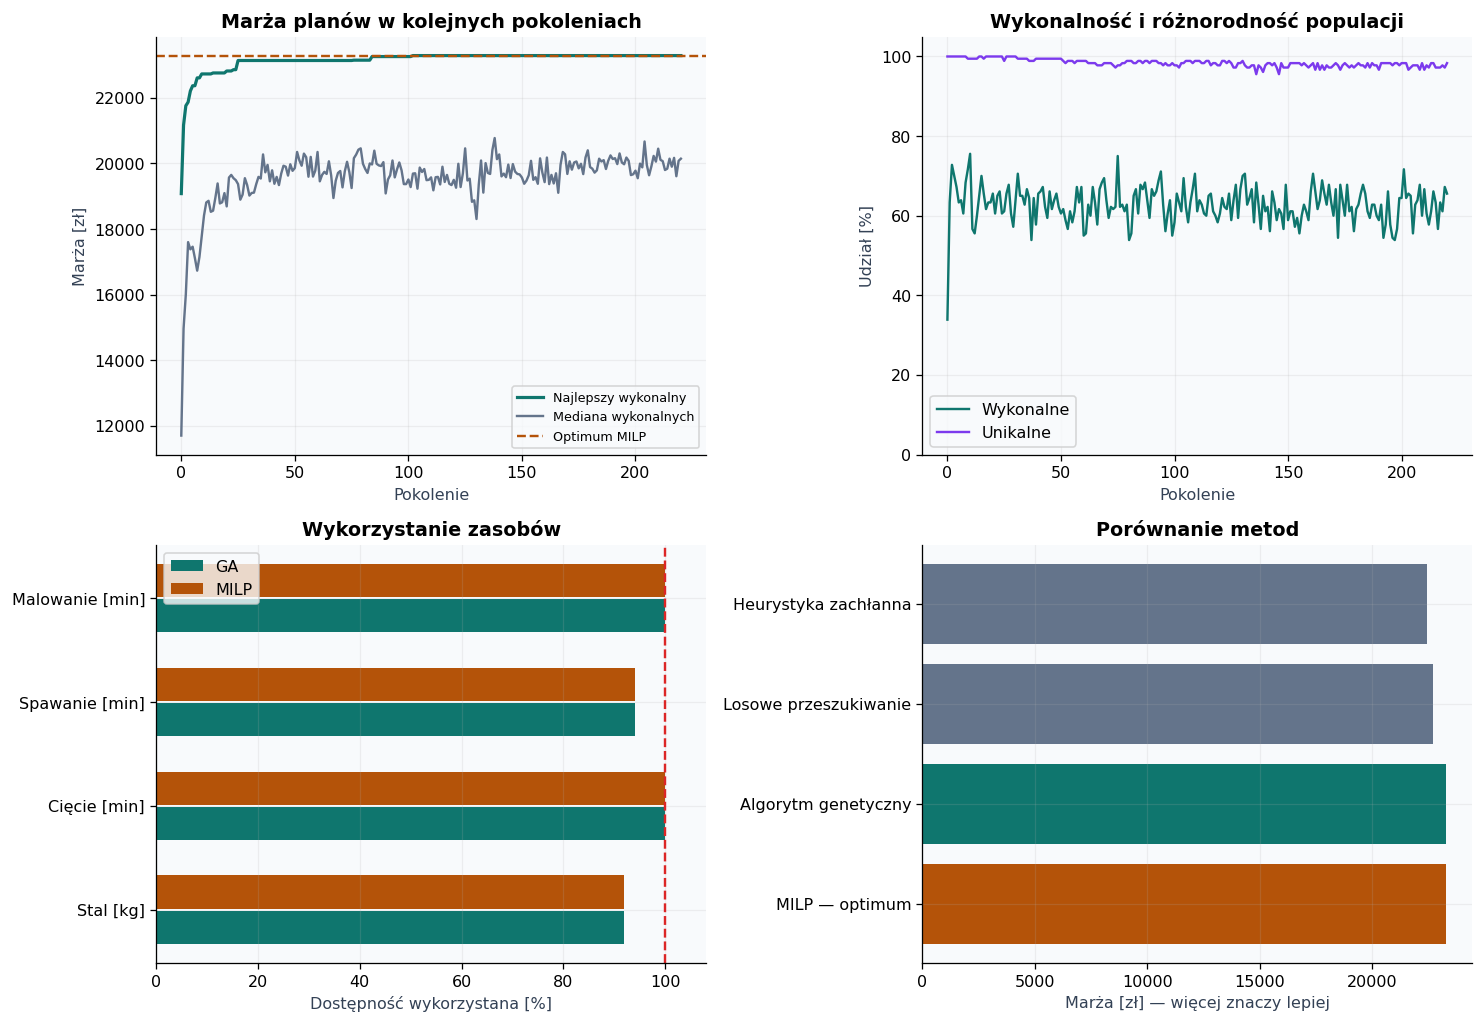

In [9]:
plan_table = products[['Produkt', 'Popyt [partie]', 'Marża [zł/partię]']].copy()
plan_table['Plan zachłanny'] = greedy
plan_table['Plan GA'] = ga['plan']
plan_table['Plan MILP'] = exact['plan']
plan_table['Marża planu GA [zł]'] = ga['plan'] * profit
display(plan_table)

ga_usage = A @ ga['plan']
exact_usage = A @ exact['plan']
resources = pd.DataFrame({
    'Zasób': resource_names, 'Dostępność': CAPACITY,
    'Zużycie GA': ga_usage, 'Pozostało GA': CAPACITY - ga_usage,
    'Wykorzystanie GA [%]': 100 * ga_usage / CAPACITY,
    'Wykorzystanie MILP [%]': 100 * exact_usage / CAPACITY,
})
display(resources.round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
h = ga['history']
axes[0, 0].plot(h.pokolenie, h.najlepsza_marza, c=COLORS['ga'], lw=2, label='Najlepszy wykonalny')
axes[0, 0].plot(h.pokolenie, h.mediana_marzy_wykonalnych, c=COLORS['base'], label='Mediana wykonalnych')
axes[0, 0].axhline(exact['margin'], c=COLORS['exact'], ls='--', label='Optimum MILP')
axes[0, 0].set(title='Marża planów w kolejnych pokoleniach', xlabel='Pokolenie', ylabel='Marża [zł]')
axes[0, 0].legend(fontsize=8)
axes[0, 1].plot(h.pokolenie, 100*h.udzial_wykonalnych, label='Wykonalne', c=COLORS['ga'])
axes[0, 1].plot(h.pokolenie, 100*h.udzial_roznych_planow, label='Unikalne', c=COLORS['accent'])
axes[0, 1].set(title='Wykonalność i różnorodność populacji', xlabel='Pokolenie', ylabel='Udział [%]', ylim=(0, 105))
axes[0, 1].legend()
y = np.arange(len(resource_names))
axes[1, 0].barh(y-0.17, 100*ga_usage/CAPACITY, height=0.32, label='GA', color=COLORS['ga'])
axes[1, 0].barh(y+0.17, 100*exact_usage/CAPACITY, height=0.32, label='MILP', color=COLORS['exact'])
axes[1, 0].set_yticks(y, resource_names)
axes[1, 0].axvline(100, ls='--', color='#dc2626')
axes[1, 0].set(title='Wykorzystanie zasobów', xlabel='Dostępność wykorzystana [%]', xlim=(0, 108))
axes[1, 0].legend()
axes[1, 1].barh(comparison['Metoda'], comparison['Marża [zł]'], color=[COLORS['base'], COLORS['base'], COLORS['ga'], COLORS['exact']])
axes[1, 1].set(title='Porównanie metod', xlabel='Marża [zł] — więcej znaczy lepiej')
axes[1, 1].invert_yaxis()
fig.tight_layout()
plt.show()

### 9. Rozwiązany eksperyment: stabilność GA w pięciu uruchomieniach

W każdym uruchomieniu stosujemy te same dane, ograniczenia i budżet. Zmienia się tylko seed. Każdy wynik musi być wykonalny. Raportujemy lukę względem **tej samej** referencji MILP.

In [10]:
seeds = [7, 17, 27, 37, 47]
runs = {7: ga}
for seed in seeds[1:]:
    runs[seed] = genetic_production(CAPACITY, seed=seed, **CONFIG)
stability = pd.DataFrame([
    {'Seed': seed, 'Marża [zł]': result['margin'],
     'Luka [%]': max(0, 100 * (exact['margin'] - result['margin']) / exact['margin']),
     'Wykonalny': plan_is_feasible(result['plan']), 'Czas [s]': result['seconds']}
    for seed, result in runs.items()
])
display(stability.round(4))
display(stability[['Marża [zł]', 'Luka [%]']].agg(['min', 'median', 'max']).round(4))

,Seed,Marża [zł],Luka [%],Wykonalny,Czas [s]
0,7,23290.0,0.0000,True,0.0902
1,17,23280.0,0.0429,True,0.0855
2,27,23110.0,0.7729,True,0.0878
3,37,23070.0,0.9446,True,0.0795
4,47,23270.0,0.0859,True,0.0804


,Marża [zł],Luka [%]
min,23070.0,0.0000
median,23270.0,0.0859
max,23290.0,0.9446


### 10. Rozwiązany eksperyment biznesowy: którego zasobu brakuje?

Zwiększamy **po jednym zasobie o 15%** i za każdym razem ponownie rozwiązujemy model dokładny. Pozostałe zasoby oraz popyt pozostają bez zmian. Otrzymujemy wpływ konkretnej zmiany na maksymalną marżę modelu.

To dyskretna analiza scenariuszy, a nie ciągła „cena dualna”. Odpowiedź może być skokowa przez całkowite partie. Zwiększenie dwóch zasobów naraz może mieć inny efekt niż suma dwóch osobnych zmian.

Dla scenariusza o największym przyroście uruchamiamy także GA. Nie zakładamy z góry, że bardziej obciążony zasób musi dać największą poprawę.

Wybrany scenariusz: +15% Malowanie [min]
GA: 24,510 zł | optimum scenariusza: 24,620 zł | luka: 0.447%


,Zwiększony zasób,Dodatkowa dostępność,Optimum po zmianie [zł],Przyrost marży [zł]
0,Stal [kg],285.0,23290.0,0.0
1,Cięcie [min],147.0,23800.0,510.0
2,Spawanie [min],217.5,23290.0,0.0
3,Malowanie [min],105.0,24620.0,1330.0


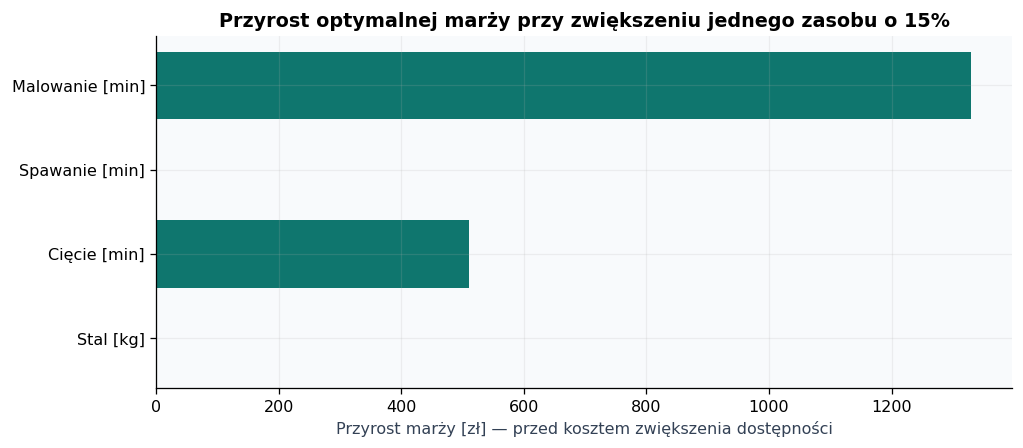

In [11]:
scenario_rows = []
scenario_solutions = {}
for idx, resource in enumerate(resource_names):
    capacity = CAPACITY.copy()
    capacity[idx] *= 1.15
    solution = exact_production(capacity)
    scenario_solutions[idx] = (capacity, solution)
    scenario_rows.append({
        'Zwiększony zasób': resource,
        'Dodatkowa dostępność': capacity[idx] - CAPACITY[idx],
        'Optimum po zmianie [zł]': solution['margin'],
        'Przyrost marży [zł]': solution['margin'] - exact['margin'],
    })
scenarios = pd.DataFrame(scenario_rows)
display(scenarios.round(2))
best_idx = int(scenarios['Przyrost marży [zł]'].idxmax())
expanded_capacity, expanded_exact = scenario_solutions[best_idx]
expanded_ga = genetic_production(expanded_capacity, seed=7, **CONFIG)
scenario_gap = max(0, 100 * (expanded_exact['margin'] - expanded_ga['margin']) / expanded_exact['margin'])
print(f'Wybrany scenariusz: +15% {resource_names[best_idx]}')
print(f"GA: {expanded_ga['margin']:,.0f} zł | optimum scenariusza: {expanded_exact['margin']:,.0f} zł | luka: {scenario_gap:.3f}%")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(scenarios['Zwiększony zasób'], scenarios['Przyrost marży [zł]'], color=COLORS['ga'])
ax.set(title='Przyrost optymalnej marży przy zwiększeniu jednego zasobu o 15%', xlabel='Przyrost marży [zł] — przed kosztem zwiększenia dostępności')
fig.tight_layout()
plt.show()

### 11. Rozwiązanie: ile najwyżej warto zapłacić za tę dodatkową dostępność?

Przyrost optymalnej marży jest górną granicą kosztu zwiększenia zasobu, przy której model pozostaje na progu opłacalności. To wartość dla całego **dodatkowego pakietu dostępności w analizowanym okresie**, a nie uniwersalna stawka za kilogram czy minutę.

Przyjmijmy dydaktycznie, że pakiet kosztuje 60% dodatkowej marży. Poniżej obliczamy zmianę wyniku po tym koszcie. W rzeczywistej decyzji trzeba wprowadzić rzeczywistą ofertę, a nie przyjęte tu 60%.

In [12]:
extra_margin = expanded_exact['margin'] - exact['margin']
illustrative_cost = 0.60 * extra_margin
net_change = extra_margin - illustrative_cost
display(pd.DataFrame({
    'Wielkość': ['Przyrost marży modelu', 'Przykładowy koszt pakietu (60%)', 'Zmiana po koszcie pakietu'],
    'Kwota [zł]': [extra_margin, illustrative_cost, net_change],
}))
display(Markdown(f"""
W scenariuszu **+15% {resource_names[best_idx]}** dodatkowa marża wynosi **{extra_margin:,.0f} zł**.
To próg kosztu pakietu dla zerowej zmiany wyniku w tym uproszczonym modelu.
Przy przyjętym przykładowym koszcie **{illustrative_cost:,.0f} zł** pozostaje **{net_change:,.0f} zł**.
Wycena nie obejmuje nowych kosztów stałych, ryzyka braku sprzedaży ani kosztów wdrożenia zmiany.
"""))

,Wielkość,Kwota [zł]
0,Przyrost marży modelu,1330.0
1,Przykładowy koszt pakietu (60%),798.0
2,Zmiana po koszcie pakietu,532.0



W scenariuszu **+15% Malowanie [min]** dodatkowa marża wynosi **1,330 zł**.
To próg kosztu pakietu dla zerowej zmiany wyniku w tym uproszczonym modelu.
Przy przyjętym przykładowym koszcie **798 zł** pozostaje **532 zł**.
Wycena nie obejmuje nowych kosztów stałych, ryzyka braku sprzedaży ani kosztów wdrożenia zmiany.


### 12. Kontrole poprawności

Sprawdzamy całkowitość, limity popytu, wszystkie dostępności i monotoniczność najlepszego wykonalnego wyniku. Sprawdzamy również, że poluzowanie ograniczenia nie obniżyło optimum oraz że reguła selekcji nie wybiera planu niewykonalnego tylko dlatego, że ma wysoką marżę.

In [13]:
for result in [ga, exact, random_result, *runs.values()]:
    assert plan_is_feasible(result['plan'])
    assert result['margin'] <= exact['margin'] + 1e-6
assert plan_is_feasible(greedy)
assert np.all(np.diff(ga['history'].najlepsza_marza) >= -1e-8)
assert np.all(ga['history'].udzial_wykonalnych > 0)
assert plan_is_feasible(expanded_ga['plan'], expanded_capacity)
assert expanded_ga['margin'] <= expanded_exact['margin'] + 1e-6
assert np.all(scenarios['Przyrost marży [zł]'] >= -1e-6)

# Wykonalny o marży 50 wygrywa z niewykonalnym o marży 1000.
test_order = rank_plans(np.array([1000., 50., 40.]),
                       np.array([0.1, 0.0, 0.0]), np.array([False, True, True]))
assert np.array_equal(test_order, [1, 2, 0])
# Wśród niewykonalnych mniejsze przekroczenie jest ważniejsze od marży.
test_order = rank_plans(np.array([1000., 50.]), np.array([0.2, 0.1]), np.array([False, False]))
assert np.array_equal(test_order, [1, 0])
assert np.array_equal(rank_plans(np.array([60., 50.]), np.array([1e-12, 0.]), np.array([True, True])), [0, 1])
print('OK: całkowitość, popyt, zasoby, selekcja, elityzm i odniesienie MILP.')

OK: całkowitość, popyt, zasoby, selekcja, elityzm i odniesienie MILP.


### 13. Automatyczna interpretacja wyniku

In [14]:
gap = max(0, 100 * (exact['margin'] - ga['margin']) / exact['margin'])
delta_greedy = ga['margin'] - float(profit @ greedy)
direction = 'większa' if delta_greedy >= 0 else 'mniejsza'
display(Markdown(f"""
**Plan GA daje {ga['margin']:,.0f} zł marży** i spełnia wszystkie ograniczenia.
Jego marża jest o **{abs(delta_greedy):,.0f} zł {direction}** od planu zachłannego.
Optimum referencyjne wynosi **{exact['margin']:,.0f} zł**, więc luka GA to **{gap:.3f}%**.

**Pięć uruchomień:** mediana luki wynosi **{stability['Luka [%]'].median():.3f}%**,
a najgorsza luka **{stability['Luka [%]'].max():.3f}%**. Ten zakres opisuje tę instancję i konfigurację,
nie ogólną skuteczność algorytmów genetycznych.

**Analiza dostępności:** największy przyrost wśród badanych pojedynczych zmian daje **+15% {resource_names[best_idx]}**:
**{extra_margin:,.0f} zł** dodatkowej optymalnej marży przed kosztem pozyskania zasobu.
GA w tym scenariuszu ma lukę **{scenario_gap:.3f}%** względem nowego optimum.

**Wniosek wdrożeniowy:** dla obecnego modelu liniowego użyjemy w pierwszej kolejności MILP.
Implementacja GA pokazuje alternatywny mechanizm wyszukiwania i nadaje się do dalszych eksperymentów
z bardziej złożoną funkcją oceny.
"""))


**Plan GA daje 23,290 zł marży** i spełnia wszystkie ograniczenia.
Jego marża jest o **850 zł większa** od planu zachłannego.
Optimum referencyjne wynosi **23,290 zł**, więc luka GA to **0.000%**.

**Pięć uruchomień:** mediana luki wynosi **0.086%**,
a najgorsza luka **0.945%**. Ten zakres opisuje tę instancję i konfigurację,
nie ogólną skuteczność algorytmów genetycznych.

**Analiza dostępności:** największy przyrost wśród badanych pojedynczych zmian daje **+15% Malowanie [min]**:
**1,330 zł** dodatkowej optymalnej marży przed kosztem pozyskania zasobu.
GA w tym scenariuszu ma lukę **0.447%** względem nowego optimum.

**Wniosek wdrożeniowy:** dla obecnego modelu liniowego użyjemy w pierwszej kolejności MILP.
Implementacja GA pokazuje alternatywny mechanizm wyszukiwania i nadaje się do dalszych eksperymentów
z bardziej złożoną funkcją oceny.


### Głębsze dno: optymalizacja zawsze dziedziczy założenia modelu

**Algorytm nie wie, co znaczy dobry biznes.** Maksymalizuje sumę zadanych marż. Może pominąć produkt ważny dla relacji z klientem, jeżeli nie zapisaliśmy obowiązku jego dostarczenia. Jeżeli musimy wyprodukować minimum określonego wyrobu, trzeba dodać dolne ograniczenie i dostosować start oraz operatory. Wówczas plan zerowy przestanie być punktem wykonalnym.

**Wykonalność jest częścią jakości.** Plan za 50 000 zł, który wymaga dwa razy więcej zasobów niż dostępne, nie jest lepszy od planu za 25 000 zł możliwego do wykonania. Ranga oddziela fizyczne ograniczenia od wartości ekonomicznej. Normalizacja przekroczeń nadal zawiera wybór modelującego: tutaj każdy zasób liczy się przez swój względny deficyt.

**To nie jest OneMax pod inną nazwą.** Geny są ograniczonymi liczbami całkowitymi; produkty mają różne marże i różne profile zużycia. Zwiększenie jednego genu może odebrać zasoby kilku innym produktom. Optimum jest efektem kompromisu, a nie maksymalizacji każdej pozycji osobno.

**GA zmienia rozkład kandydatów.** Selekcja premiuje określone kombinacje ilości, krzyżowanie je miesza, a mutacja bada sąsiednie i dalsze plany. Gdy zmieniamy ograniczenia, zmienia się obszar dopuszczalny i znaczenie tych samych genów.

**Najlepszy model matematyczny może być złą prognozą.** Marże, popyt i wydajność nie są w rzeczywistości pewne. Wersja operacyjna powinna porównywać scenariusze, aktualizować dane i walidować harmonogram wykonania. Dodanie kosztów przezbrojeń zależnych od kolejności wymaga reprezentacji kolejności, której ten wektor ilości nie zawiera.

### Gotowe odpowiedzi do dyskusji

- **Czy brak naruszeń oznacza pełny harmonogram wykonalny na hali?** Nie. Tu sprawdzamy sumy zużycia zasobów w okresie, a nie kolejność i współbieżność operacji.
- **Dlaczego nie po prostu kara pieniężna za przekroczenia?** Kara wymaga ustalenia przelicznika zasobów na złote i może dopuścić „opłacalne” łamanie ograniczeń. Użyta reguła traktuje je jako twarde.
- **Czy najwyższa marża jednostkowa powinna wygrywać?** Nie zawsze. Liczy się także zużycie ograniczonych zasobów oraz popyt na inne produkty.
- **Czy GA musi odtworzyć plan MILP?** Nie. Różne plany mogą dać to samo optimum. Porównujemy marżę i spełnienie ograniczeń.
- **Dlaczego raportujemy kilka seedów?** Aby nie pomylić szczęśliwego wyniku z powtarzalnością. Do wyboru metody produkcyjnej potrzeba też wielu różnych instancji danych.
- **Jak użyć własnych danych?** Zmień tabelę `products` i `CAPACITY`, zachowaj spójne jednostki, dodatnie dostępności i nieujemne zużycia. Uruchom wszystko ponownie. Bazowa wersja nie obsługuje zasobów o zerowej dostępności ani obowiązkowych minimów produkcji.

**Źródło referencji MILP:** [oficjalna dokumentacja `scipy.optimize.milp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.milp.html) opisuje minimalizację, całkowitość, ograniczenia liniowe i statusy rozwiązania. Kod GA, dane oraz analiza scenariuszy są zawarte w tym notebooku.